In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import gc
from pathlib import Path
from define_data_and_variables import pt_config, data, hash_configs, version

In [ ]:
base_dir = Path.cwd()

base_path = base_dir / ".." / ".." / ".." / ".." / "data"
data_name = rf"$A_{{{data["dn"][:3]}}}$"
true_sample = np.load(base_path / data["dn"] / version / "true_sample.npy")
int_version = int(version)
true_ages = np.hstack((data["th"], data["th"] - np.cumsum(true_sample) * data["dc"]))
c14_label = r"$^{230}$Th" if "d18o" in data["dn"] else r"$^{14}$C"
measure = "mm" if "d18o" in data["dn"] else "cm"


c:\Users\hanna\Desktop\PhD\Bacon\python\src\age_depth_models\age_depth_model_PT_normal_c14_d18o


In [ ]:
base_dir = Path.cwd()
sp_dir = base_dir / f"output/{data['dn']}/{version}"
np.random.seed(pt_config['hmcc']['sd'])
sp = np.random.lognormal(mean = data["pm"], sigma = data["ps"], size = (pt_config["nt"], data["N"]))
pt_config["hmcc"]["sp"] = np.ascontiguousarray(sp)

pt_hash = hash_configs(pt_config, data)
output_dir = sp_dir / f"{pt_hash}"

hmc_config = pt_config["hmcc"]

In [4]:
colors = plt.cm.viridis(np.linspace(0, 1, pt_config["nt"]))

[[ 2 10 10 ... 23 23 23]
 [10  2 26 ... 14 14  7]
 [26 26  2 ... 27  7 14]
 ...
 [ 3  3  3 ...  2  2  2]
 [27 27 27 ... 15 15 15]
 [17 17 17 ...  0  0  0]]
(30, 50001)
[[ 2 10 10 ... 23 23 23]
 [10  2 26 ... 14 14  7]
 [26 26  2 ... 27  7 14]
 ...
 [ 3  3  3 ...  2  2  2]
 [27 27 27 ... 15 15 15]
 [17 17 17 ...  0  0  0]]


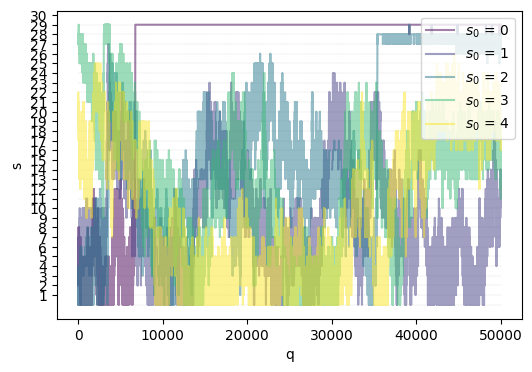

In [ ]:
import matplotlib as mpl
cutout = 50000
num_starts = 5
temp_indices = np.load(output_dir / "temp_indices.npy", mmap_mode='r')[:, cutout:]
norm = mpl.colors.Normalize(vmin=min(pt_config['bs'][0:num_starts]), vmax=max(pt_config['bs'][0:num_starts]))
cmap = plt.cm.viridis
print(temp_indices)
print(np.shape(temp_indices))
plt.figure(figsize=(6, 4))
xmin = 0
xmax = len(temp_indices[0, :])
# for i in range(len(temp_indices)):
plt.hlines(np.linspace(0, pt_config["nt"] - 1, pt_config["nt"]), linestyle = '--', color = "grey", linewidth = 0.1,  xmin = xmin, xmax = xmax)
for i in range(0, num_starts):
    temp_indices_i = (temp_indices == i).argmax(axis=0)
    plt.plot(np.arange(xmin, xmax, 1), temp_indices_i[xmin:xmax], label = r"$s_0$" + f" = {i}", color = cmap(norm(pt_config['bs'][i])), alpha = 0.5)  
print(temp_indices)
plt.yticks(np.linspace(1, pt_config["nt"], pt_config["nt"]))
plt.ylabel("s")
plt.xlabel("q")
plt.legend(loc = "upper right")
plt.savefig(f"{output_dir}/index_evolution.jpg")
plt.show()


In [19]:
backwards = False
round_trip = 0
num_temps = len(temp_indices)
num_samples = len(temp_indices[0, cutout:])
for chain in range(num_temps):
    for col in range(num_samples):
        if temp_indices[0, col] == chain and backwards:
            round_trip+=1
            backwards = False
        if temp_indices[-1, col] == chain:
            backwards = True
print(round_trip / (num_samples * num_temps))


0.0


In [20]:
samples = np.load(output_dir / "samples.npy", mmap_mode='r')[:, cutout:, :]

In [ ]:
import arviz as az
ess_array = np.array([az.ess(samples[-1, :, i], method = "bulk") for i in range(len(samples[-1, 0, :]))])
print(ess_array)
min_ess = np.min(ess_array)
print(min_ess)

[3.11848519e+02 3.94410496e+02 3.40598644e+03 7.56637224e+03
 3.04164367e+02 1.15213027e+02 1.74959594e+01 2.07282062e+01
 4.53402361e+01 9.51462580e+00 2.19190674e+01 1.01646700e+02
 7.41002620e+01 3.05868310e+01 2.42981888e+01 3.07925757e+02
 3.27625861e+04 2.38612199e+04 5.02436590e+04 1.35760102e+04
 1.24882681e+04 3.06681109e+04 1.46895652e+04 2.32892906e+04
 1.31910139e+04 1.52988058e+04 1.93645347e+04 3.18587526e+01
 3.26662595e+01 4.45703917e+01 9.54501401e+00 1.12883354e+01
 4.76545366e+02 2.93535972e+03 1.81621544e+02 7.31722972e+01
 7.02353793e+01 6.86839466e+01 7.36330718e+01 1.04574347e+02
 5.74103521e+01 8.03658134e+01 1.94511124e+01 9.65229505e+00
 5.21771373e+01 7.15276672e+01 3.65798629e+01 3.66768987e+02
 4.32436696e+02 4.81271951e+02]
9.51462579723994


In [ ]:
energy_values = np.load(output_dir / "energy.npy", mmap_mode='r')[:, cutout:]
d18o_energy_values = np.load(output_dir / "d18o_energy.npy", mmap_mode='r')[:, cutout:]

In [ ]:
for i in range(0, pt_config["nt"] - 1):
    temp_indices_i = (temp_indices == i).argmax(axis=0)
    print(np.min(temp_indices_i))
    rej_indices = np.where((np.diff(temp_indices_i) == 0) & (temp_indices_i[:-1] != pt_config["nt"] - 1))[0]
    print(rej_indices)
    rej = 0
    for j in range(len(rej_indices)):
        rej+= 1 - np.min([1, np.exp((pt_config["bs"][temp_indices_i[rej_indices][j] + 1] - pt_config["bs"][temp_indices_i[rej_indices][j]]) * (d18o_energy_values[temp_indices_i[rej_indices][j] + 1, rej_indices][j] - d18o_energy_values[temp_indices_i[rej_indices][j], rej_indices][j]))])
    print(rej / pt_config["hmcc"]["ns"])

In [ ]:
print(d18o_energy_values)

[[4737.45206655 4793.08488612 5044.41958526 ... 4328.21399896
  3976.89104622 4100.76005148]
 [4735.83033012 4215.12476302 3730.70132615 ... 3895.38332326
  3881.27607766 3614.11176304]
 [4006.0742333  3986.44055325 3753.58256472 ... 3751.45054913
  3554.91876932 3282.79351087]
 ...
 [ 713.58152502  714.61835684  709.94227619 ...  421.33369294
   433.02066105  439.2588398 ]
 [ 701.39415935  707.87738642  707.59702616 ...  451.17020649
   416.05511726  415.47640196]
 [ 690.52661313  682.71644832  677.36030424 ...  389.02566543
   394.27520028  397.5880325 ]]


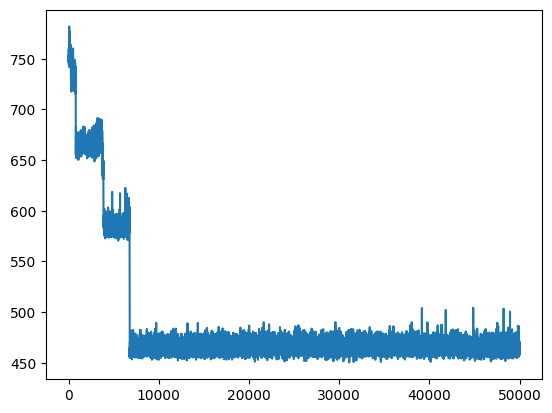

In [25]:
plt.figure()
chain = -1
plt.plot(energy_values[chain] - (pt_config["bs"][chain] - 1) * d18o_energy_values[chain])
plt.show()

In [26]:
# chain = -1
# fig, ax = plt.subplots(figsize=(6, 4))
# plt.plot(data["cs"], data["th"] - data["dc"]*np.hstack(([0], np.cumsum(min_energy_samples[chain]))), color = "black", alpha = 1, linewidth = 1, label = r"$A_{max}(d)$")
# ax.plot(data["cs"], true_ages, color = "red", linewidth=1, alpha = 1, label = data_name + "(d)")
# for i, c in enumerate(data["cs"]):
#     ax.axvline(x=c, color='k', linestyle='--', linewidth = 0.1)

# ax.plot(data["c14d"], np.squeeze(data["c14"]), "ko", markersize=4, label = c14_label)
# plt.xlabel("Distance from top of stalagmite [" + measure + "]")
# plt.ylabel("Year CE")
# plt.legend()
# plt.savefig(f"{output_dir}/max_prob_sol.jpg")
# plt.show()

# fig, ax = plt.subplots(figsize=(6, 4))
# plt.plot(data["cs"], data["th"] - data["dc"]*np.hstack(([chain], np.cumsum(closest_to_true_samples[chain]))), color = "black", alpha = 1, linewidth = 0.5, label = r"$A_{close}(d)$")
# ax.plot(data["cs"], true_ages, color = "red", linewidth=1, alpha = 1, label = data_name + "(d)")
# for i, c in enumerate(data["cs"]):
#     ax.axvline(x=c, color='k', linestyle='--', linewidth = 0.1)

# ax.plot(data["c14d"], np.squeeze(data["c14"]), "ko", markersize=4, label = c14_label)
# plt.xlabel("Distance from top of stalagmite [" + measure + "]")
# plt.ylabel("Year CE")
# plt.legend()
# plt.savefig(f"{output_dir}/close_prob_sol.jpg")
# plt.show()

In [27]:
index = 12
interesting_depth = index * data["dc"]

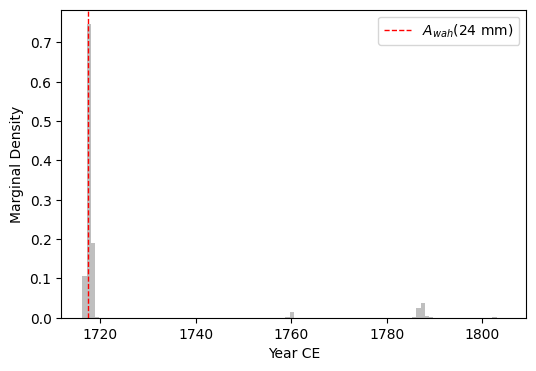

In [28]:
CV_values = data["th"] - data["dc"] * np.sum(samples[-1, :, :index], axis = 1)
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(CV_values, bins = 100, color = "grey", alpha = 0.5, density = True)
ax.set_xlabel("Year CE")
ax.set_ylabel("Marginal Density")
ax.axvline(x=true_ages[index], color="red", linestyle='--', linewidth = 1, label = data_name + f"({int(interesting_depth)} " + measure + ")")
plt.legend()
plt.savefig(f"{output_dir}/samples_along_depth_{interesting_depth}.jpg")
plt.show()

c:\Users\hanna\Desktop\PhD\Bacon\bacon_venv\Lib\site-packages\numpy\lib\_histograms_impl.py:901: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


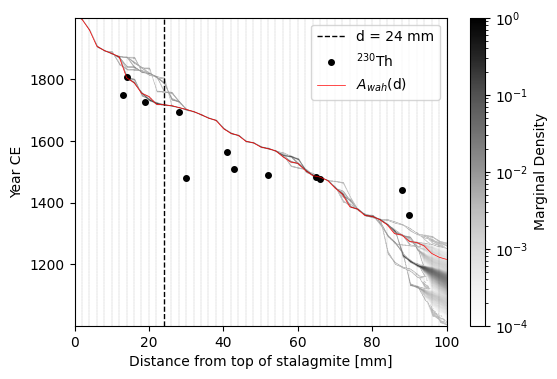

27057

In [ ]:
from matplotlib import colors

X = samples[-1, :, :].T
D, N = X.shape

age = np.vstack([
    np.ones((1, N)) * data["th"],
    data["th"] - data["dc"] * np.cumsum(X, axis=0)
])

norm_age = age

# Time bins
dt = 1
t_edges = np.arange(np.min(data["d18ort"]), np.max(data["d18ort"]) + dt, dt)
t = t_edges[1:] - dt / 2
T = t.size

# Depth interpolation grid
dz = 0.1
z = np.arange(0, data["dc"] * D + dz, dz)
Z = z.size

# Allocate result
C = np.full((Z, T), np.nan)
A = np.array([
    np.interp(z, data["cs"], norm_age[:, j])
    for j in range(N)
]).T

for i in range(Z):
    C[i, :], _ = np.histogram(A[i, :], bins=t_edges, density = True)

fig, ax = plt.subplots(figsize=(6, 4))
plt.set_cmap(plt.cm.Greys)
for i, c in enumerate(data["cs"]):
    if i ==index: 
        ax.axvline(x=c, color='k', linestyle='--', linewidth = 1, label = f"d = {int(interesting_depth)} " + measure)
    else:
        ax.axvline(x=c, color='k', linestyle='--', linewidth = 0.1)

ax.plot(data["c14d"], np.squeeze(data["c14"]), "ko", markersize=4, label = c14_label)
ax.plot(data["cs"], true_ages, color = "red", linewidth=0.5, alpha = 1, label = data_name + "(d)")
im = ax.imshow(
    C.T,
    extent=[z[0], z[-1], t[0], t[-1]],
    origin='lower',
    aspect='auto',
    norm=colors.LogNorm(1e-4, 1)
)

plt.legend(loc = "upper right")
cbar = plt.colorbar(im)
cbar.set_label("Marginal Density")
plt.xlabel("Distance from top of stalagmite [" + measure + "]")
plt.ylabel("Year CE")
plt.savefig(f"{output_dir}/resampled_no_mean.jpg")
plt.show()

del A, C
gc.collect()


c:\Users\hanna\Desktop\PhD\Bacon\bacon_venv\Lib\site-packages\numpy\lib\_histograms_impl.py:901: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


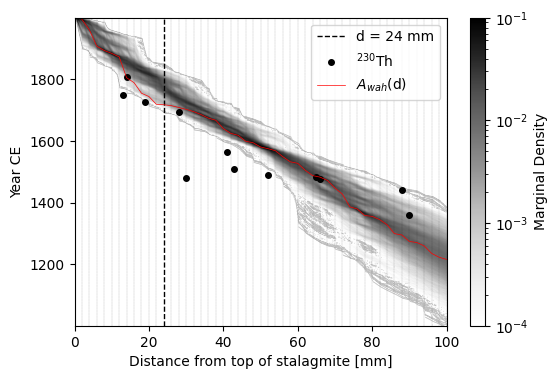

16818

In [ ]:
from matplotlib import colors

X = samples[0, :, :].T
D, N = X.shape

age = np.vstack([
    np.ones((1, N)) * data["th"],
    data["th"] - data["dc"] * np.cumsum(X, axis=0)
])

norm_age = age

# Time bins
dt = 1
t_edges = np.arange(np.min(data["d18ort"]), np.max(data["d18ort"]) + dt, dt)
t = t_edges[1:] - dt / 2
T = t.size

# Depth interpolation grid
dz = 0.1
z = np.arange(0, data["dc"] * D + dz, dz)
Z = z.size

# Allocate result
C = np.full((Z, T), np.nan)
A = np.array([
    np.interp(z, data["cs"], norm_age[:, j])
    for j in range(N)
]).T

for i in range(Z):
    C[i, :], _ = np.histogram(A[i, :], bins=t_edges, density = True)

fig, ax = plt.subplots(figsize=(6, 4))
plt.set_cmap(plt.cm.Greys)
for i, c in enumerate(data["cs"]):
    if i ==index: 
        ax.axvline(x=c, color='k', linestyle='--', linewidth = 1, label = f"d = {int(interesting_depth)} " + measure)
    else:
        ax.axvline(x=c, color='k', linestyle='--', linewidth = 0.1)

ax.plot(data["c14d"], np.squeeze(data["c14"]), "ko", markersize=4, label = c14_label)
ax.plot(data["cs"], true_ages, color = "red", linewidth=0.5, alpha = 1, label = data_name + "(d)")
im = ax.imshow(
    C.T,
    extent=[z[0], z[-1], t[0], t[-1]],
    origin='lower',
    aspect='auto',
    norm=colors.LogNorm(1e-4, 1e-1)
)

plt.legend(loc = "upper right")
cbar = plt.colorbar(im)
cbar.set_label("Marginal Density")
plt.xlabel("Distance from top of stalagmite [" + measure + "]")
plt.ylabel("Year CE")
plt.savefig(f"{output_dir}/sampled_no_mean.jpg")
plt.show()

del A, C
gc.collect()
